In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.3 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torchsummary import summary
from sklearn.metrics import f1_score
import os
from torch.utils.data import Dataset
#import matplotlib.image as mpimg
from torchvision import datasets
from torchmetrics import F1Score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device:{device}')

Device:cuda


In [5]:
transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [6]:
batch_size = 64
num_classes = 6
epochs = 20
lr = 0.001
criterion = nn.CrossEntropyLoss().to(device)
train_f1_metric = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)
val_f1_metric = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)
test_f1_metric = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)

In [7]:
img_dir = '/content/drive/MyDrive/garbage_classification/Garbage classification'

In [8]:
dataset = datasets.ImageFolder(root = img_dir, transform = transform)

train_data, val_data, test_data = torch.utils.data.random_split(dataset, [0.7, 0.15, 0.15])

In [9]:
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=batch_size)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size)

In [10]:
print(f'Train size: {len(train_loader.dataset.indices)}')
print(f'Validation size: {len(val_loader.dataset.indices)}')
print(f'Test size: {len(test_loader.dataset.indices)}')

Train size: 1769
Validation size: 379
Test size: 379


In [11]:
model_names = []
model_f1s = []

## Картинки

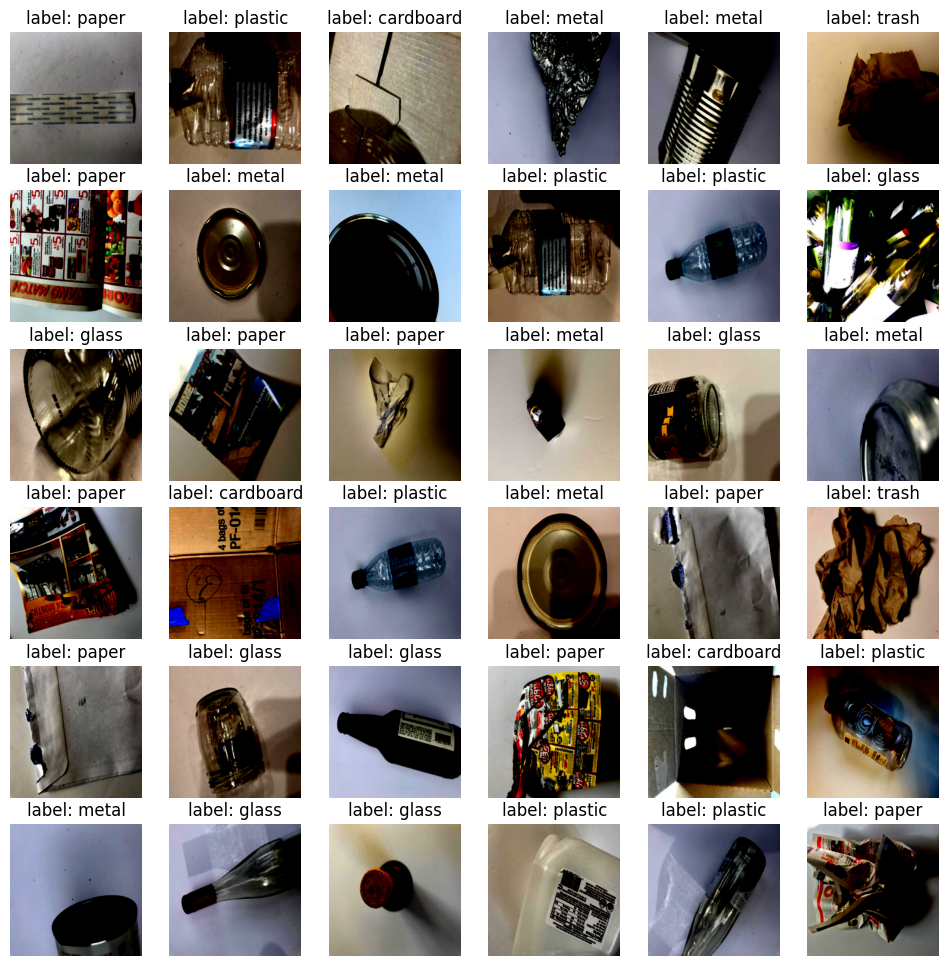

In [12]:
fig, axes = plt.subplots(6, 6, figsize=(12,12))
for image, label in train_loader:
    for i in range(6):
        for j in range(6):
            ind = i * 6 + j
            axes[i, j].imshow(image[ind].numpy().transpose(1, 2, 0))
            axes[i, j].set_title(f'label: {train_loader.dataset.dataset.classes[label[ind]]}')
            axes[i, j].axis('off')

    break
plt.show()

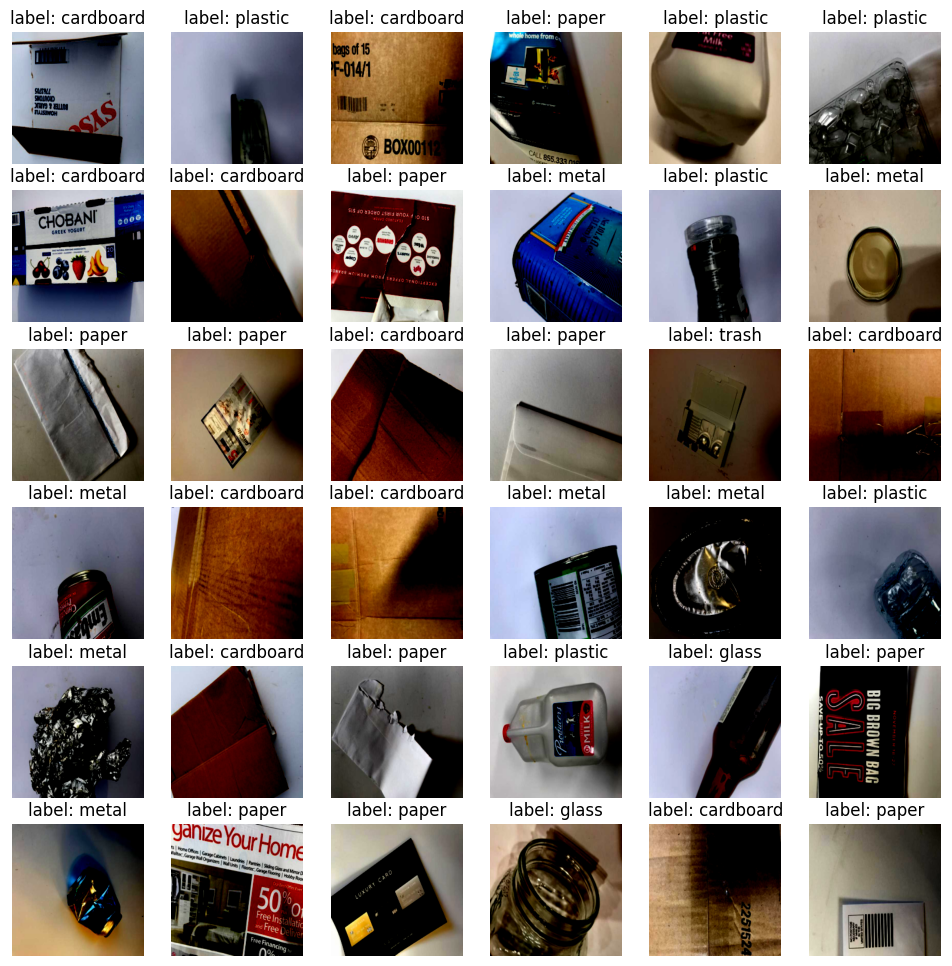

In [13]:
fig, axes = plt.subplots(6, 6, figsize=(12,12))
for image, label in val_loader:
    for i in range(6):
        for j in range(6):
            ind = i * 6 + j
            axes[i, j].imshow(image[ind].numpy().transpose(1, 2, 0))
            axes[i, j].set_title(f'label: {val_loader.dataset.dataset.classes[label[ind]]}')
            axes[i, j].axis('off')
    break
plt.show()

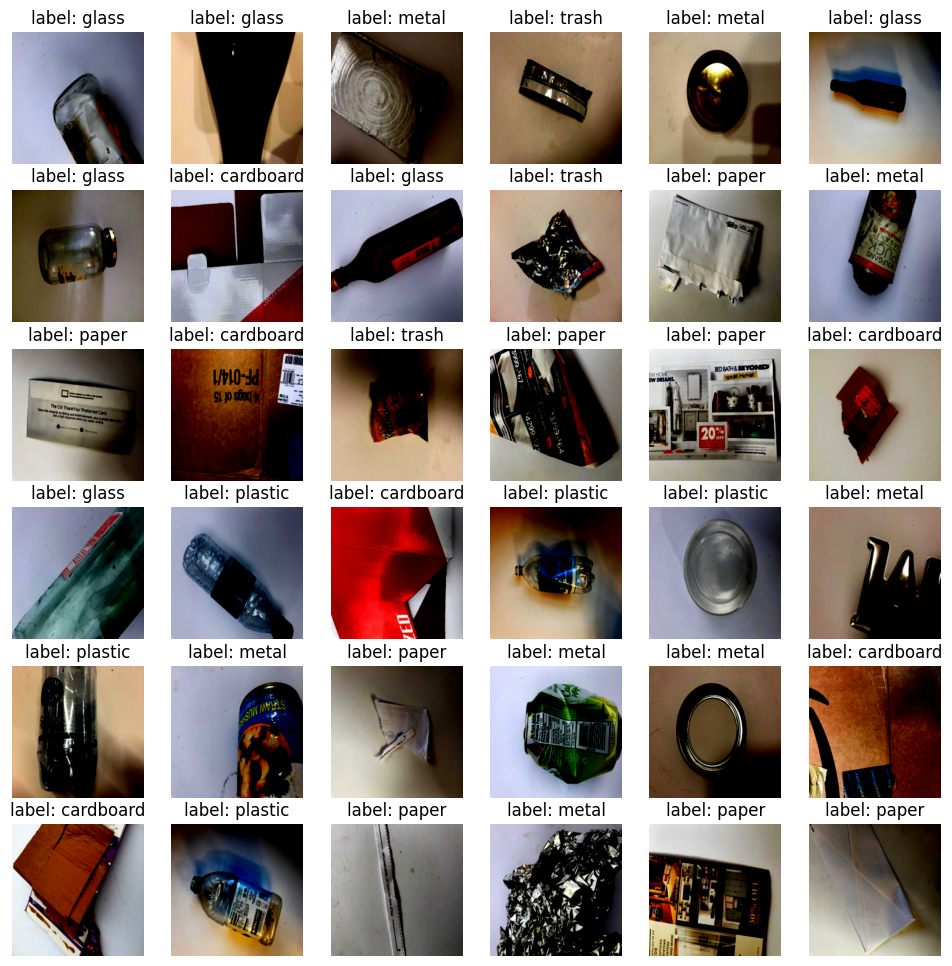

In [14]:
fig, axes = plt.subplots(6, 6, figsize=(12,12))
for image, label in test_loader:
    for i in range(6):
        for j in range(6):
            ind = i * 6 + j
            axes[i, j].imshow(image[ind].numpy().transpose(1, 2, 0))
            axes[i, j].set_title(f'label: {test_loader.dataset.dataset.classes[label[ind]]}')
            axes[i, j].axis('off')
    break
plt.show()

#ResNet34

1. Без предобучения

In [15]:
resnet34_v1 = models.resnet34(weights=None)
num_features = resnet34_v1.fc.in_features
resnet34_v1.fc = nn.Linear(num_features, 6)
optimizer = optim.Adam(resnet34_v1.parameters(), lr=lr)

In [16]:
val_losses = []
f1s_val = []

In [17]:
resnet34_v1 = resnet34_v1.to(device)

In [18]:
for epoch in range(epochs):
    resnet34_v1.train()
    train_running_loss = 0.0
    train_f1_metric.reset()

    for data in (pbar := tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')):
        images = data[0].to(device)
        labels = data[1].to(device)

        optimizer.zero_grad()
        outputs = resnet34_v1(images)

        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        train_running_loss += train_loss.item()
        train_f1_metric.update(outputs, labels)

    train_loss_ep = train_running_loss / len(train_loader)

    train_f1_ep = train_f1_metric.compute()

    print(f'Train loss: {train_loss_ep:.4f}')
    print(f'Train F1: {train_f1_ep.item():.4f}')

    resnet34_v1.eval()
    val_running_loss = 0.0
    val_f1_metric.reset()

    with torch.no_grad():
        for data in val_loader:
            images = data[0].to(device)
            labels = data[1].to(device)

            outputs = resnet34_v1(images)

            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item()
            val_f1_metric.update(outputs, labels)

    val_loss_ep = val_running_loss / len(val_loader)
    val_losses.append(val_loss_ep)

    val_f1_ep = val_f1_metric.compute()
    f1s_val.append(val_f1_ep.item())

    print(f'Validation loss: {val_loss_ep:.4f}')
    print(f'Validation F1: {val_f1_ep.item():.4f}')

Epoch 1/20: 100%|██████████| 28/28 [07:26<00:00, 15.94s/it]


Train loss: 1.6238
Train F1: 0.3545
Validation loss: 2.2491
Validation F1: 0.2343


Epoch 2/20: 100%|██████████| 28/28 [00:19<00:00,  1.43it/s]


Train loss: 1.2471
Train F1: 0.4429
Validation loss: 1.3707
Validation F1: 0.4178


Epoch 3/20: 100%|██████████| 28/28 [00:19<00:00,  1.46it/s]


...

Train loss: 0.6414
Train F1: 0.7427
Validation loss: 0.8288
Validation F1: 0.6819


Epoch 19/20: 100%|██████████| 28/28 [00:19<00:00,  1.41it/s]


Train loss: 0.6422
Train F1: 0.7365
Validation loss: 1.1679
Validation F1: 0.6274


Epoch 20/20: 100%|██████████| 28/28 [00:19<00:00,  1.40it/s]


Train loss: 0.5925
Train F1: 0.7564
Validation loss: 0.9404
Validation F1: 0.6761


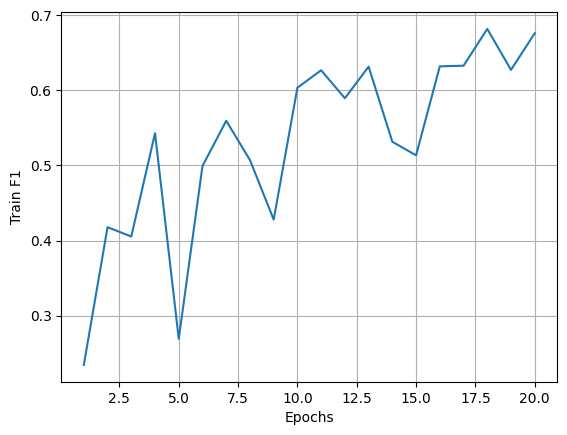

In [19]:
plt.plot(list(range(1, epochs + 1)), f1s_val)
plt.xlabel('Epochs')
plt.ylabel('Train F1')
plt.grid()
plt.show()

In [20]:
test_f1_metric.reset()
running_loss = 0.0
with torch.no_grad():
    for data in test_loader:
        images = data[0].to(device)
        labels = data[1].to(device)

        outputs = resnet34_v1(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        test_f1_metric.update(outputs, labels)

loss_test = running_loss / len(test_loader)

test_f1 = test_f1_metric.compute().item()

print(f'Loss: {loss_test:.4f}, F1: {test_f1:.4f}')

Loss: 0.9159, F1: 0.6470


In [21]:
model_f1s.append(test_f1)
model_names.append('ResNet 34 v1')

2. С весами, предобученными на ImageNet

In [22]:
resnet34_v2 = models.resnet34(weights='IMAGENET1K_V1')
for params in resnet34_v2.parameters():
        params.requires_grad = False #замораживаем веса модели
num_features = resnet34_v2.fc.in_features
resnet34_v2.fc = torch.nn.Sequential(nn.Linear(num_features, num_features // 2),
                                     nn.ReLU(),
                                     nn.Linear(num_features // 2, 6))
optimizer = optim.Adam(resnet34_v2.parameters(), lr=lr)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 216MB/s]


In [23]:
val_losses = []
f1s_val = []

In [24]:
resnet34_v2 = resnet34_v2.to(device)

In [25]:
for epoch in range(epochs):
    resnet34_v2.train()
    train_running_loss = 0.0
    train_f1_metric.reset()

    for data in (pbar := tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')):
        images = data[0].to(device)
        labels = data[1].to(device)

        optimizer.zero_grad()
        outputs = resnet34_v2(images)

        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        train_running_loss += train_loss.item()
        train_f1_metric.update(outputs, labels)

    train_loss_ep = train_running_loss / len(train_loader)

    train_f1_ep = train_f1_metric.compute()

    print(f'Train loss: {train_loss_ep:.4f}')
    print(f'Train F1: {train_f1_ep.item():.4f}')

    resnet34_v2.eval()
    val_running_loss = 0.0
    val_f1_metric.reset()

    with torch.no_grad():
        for data in val_loader:
            images = data[0].to(device)
            labels = data[1].to(device)

            outputs = resnet34_v2(images)

            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item()
            val_f1_metric.update(outputs, labels)

    val_loss_ep = val_running_loss / len(val_loader)
    val_losses.append(val_loss_ep)

    val_f1_ep = val_f1_metric.compute()
    f1s_val.append(val_f1_ep.item())

    print(f'Validation loss: {val_loss_ep:.4f}')
    print(f'Validation F1: {val_f1_ep.item():.4f}')

Epoch 1/20: 100%|██████████| 28/28 [00:14<00:00,  1.94it/s]


Train loss: 1.1999
Train F1: 0.5014
Validation loss: 0.6901
Validation F1: 0.7349


Epoch 2/20: 100%|██████████| 28/28 [00:14<00:00,  1.98it/s]


Train loss: 0.6494
Train F1: 0.7289
Validation loss: 0.4875
Validation F1: 0.7791


Epoch 3/20: 100%|██████████| 28/28 [00:13<00:00,  2.02it/s]


...

Train loss: 0.1602
Train F1: 0.9474
Validation loss: 0.3982
Validation F1: 0.8440


Epoch 19/20: 100%|██████████| 28/28 [00:13<00:00,  2.01it/s]


Train loss: 0.1354
Train F1: 0.9523
Validation loss: 0.3395
Validation F1: 0.8504


Epoch 20/20: 100%|██████████| 28/28 [00:13<00:00,  2.03it/s]


Train loss: 0.1151
Train F1: 0.9645
Validation loss: 0.3979
Validation F1: 0.8309


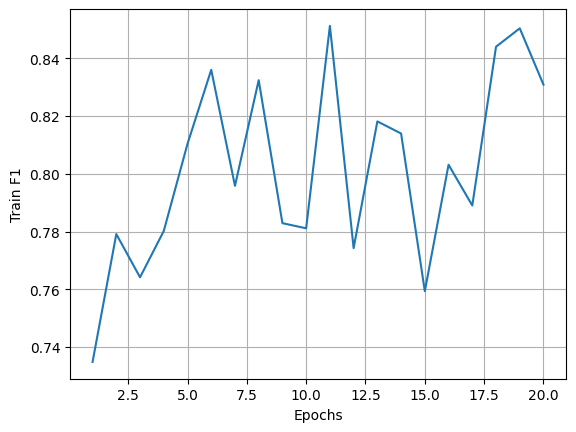

In [26]:
plt.plot(list(range(1, epochs + 1)), f1s_val)
plt.xlabel('Epochs')
plt.ylabel('Train F1')
plt.grid()
plt.show()

In [27]:
test_f1_metric.reset()
running_loss = 0.0
with torch.no_grad():
    for data in test_loader:
        images = data[0].to(device)
        labels = data[1].to(device)

        outputs = resnet34_v2(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        test_f1_metric.update(outputs, labels)

loss_test = running_loss / len(test_loader)

test_f1 = test_f1_metric.compute().item()

print(f'Loss: {loss_test:.4f}, F1: {test_f1:.4f}')

model_f1s.append(test_f1)
model_names.append('ResNet 34 v2')

Loss: 0.6029, F1: 0.8021


# ViT-Base 16

1. Без предобучения

In [28]:
ViT_v1 = models.vit_b_16(weights=None)
num_features = ViT_v1.heads.head.in_features
ViT_v1.heads.head = nn.Linear(num_features, 6)
optimizer = optim.Adam(ViT_v1.parameters(), lr=lr)

In [29]:
val_losses = []
f1s_val = []

In [30]:
ViT_v1 = ViT_v1.to(device)

In [31]:
for epoch in range(epochs):
    ViT_v1.train()
    train_running_loss = 0.0
    train_f1_metric.reset()

    for data in (pbar := tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')):
        images = data[0].to(device)
        labels = data[1].to(device)

        optimizer.zero_grad()
        outputs = ViT_v1(images)

        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        train_running_loss += train_loss.item()
        train_f1_metric.update(outputs, labels)

    train_loss_ep = train_running_loss / len(train_loader)

    train_f1_ep = train_f1_metric.compute()

    print(f'Train loss: {train_loss_ep:.4f}')
    print(f'Train F1: {train_f1_ep.item():.4f}')

    ViT_v1.eval()
    val_running_loss = 0.0
    val_f1_metric.reset()

    with torch.no_grad():
        for data in val_loader:
            images = data[0].to(device)
            labels = data[1].to(device)

            outputs = ViT_v1(images)

            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item()
            val_f1_metric.update(outputs, labels)

    val_loss_ep = val_running_loss / len(val_loader)
    val_losses.append(val_loss_ep)

    val_f1_ep = val_f1_metric.compute()
    f1s_val.append(val_f1_ep.item())

    print(f'Validation loss: {val_loss_ep:.4f}')
    print(f'Validation F1: {val_f1_ep.item():.4f}')

Epoch 1/20: 100%|██████████| 28/28 [01:06<00:00,  2.39s/it]


Train loss: 2.9926
Train F1: 0.1425
Validation loss: 1.8111
Validation F1: 0.0538


Epoch 2/20: 100%|██████████| 28/28 [01:07<00:00,  2.40s/it]


Train loss: 1.7455
Train F1: 0.1262
Validation loss: 1.7141
Validation F1: 0.0545


Epoch 3/20: 100%|██████████| 28/28 [01:07<00:00,  2.41s/it]


...

Train loss: 1.4729
Train F1: 0.3340
Validation loss: 1.3711
Validation F1: 0.3099


Epoch 19/20: 100%|██████████| 28/28 [01:11<00:00,  2.54s/it]


Train loss: 1.4587
Train F1: 0.3450
Validation loss: 1.5335
Validation F1: 0.2936


Epoch 20/20: 100%|██████████| 28/28 [01:10<00:00,  2.53s/it]


Train loss: 1.5003
Train F1: 0.3096
Validation loss: 1.3308
Validation F1: 0.3946


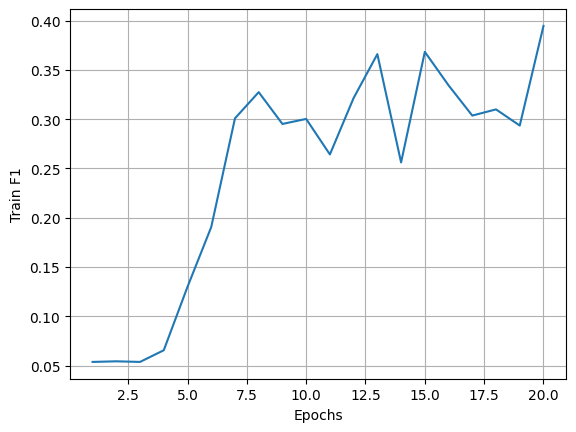

In [32]:
plt.plot(list(range(1, epochs + 1)), f1s_val)
plt.xlabel('Epochs')
plt.ylabel('Train F1')
plt.grid()
plt.show()

In [33]:
test_f1_metric.reset()
running_loss = 0.0
with torch.no_grad():
    for data in test_loader:
        images = data[0].to(device)
        labels = data[1].to(device)

        outputs = ViT_v1(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        test_f1_metric.update(outputs, labels)

loss_test = running_loss / len(test_loader)

test_f1 = test_f1_metric.compute().item()

print(f'Loss: {loss_test:.4f}, F1: {test_f1:.4f}')

model_f1s.append(test_f1)
model_names.append('ViT-Base 16 v1')

Loss: 1.5066, F1: 0.3865


2.  С весами, предобученными на ImageNet

In [34]:
ViT_v2 = models.vit_b_16(weights='IMAGENET1K_V1')
for params in ViT_v2.parameters():
        params.requires_grad = False
num_features = ViT_v2.heads.head.in_features
ViT_v2.heads.head = torch.nn.Sequential(nn.Linear(num_features, num_features // 2),
                                     nn.ReLU(),
                                     nn.Linear(num_features // 2, 6))
optimizer = optim.Adam(ViT_v2.parameters(), lr=lr)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 184MB/s]


In [35]:
val_losses = []
f1s_val = []

In [36]:
ViT_v2 = ViT_v2.to(device)

In [37]:
for epoch in range(epochs):
    ViT_v2.train()
    train_running_loss = 0.0
    train_f1_metric.reset()

    for data in (pbar := tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')):
        images = data[0].to(device)
        labels = data[1].to(device)

        optimizer.zero_grad()
        outputs = ViT_v2(images)

        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        train_running_loss += train_loss.item()
        train_f1_metric.update(outputs, labels)

    train_loss_ep = train_running_loss / len(train_loader)

    train_f1_ep = train_f1_metric.compute()

    print(f'Train loss: {train_loss_ep:.4f}')
    print(f'Train F1: {train_f1_ep.item():.4f}')

    ViT_v2.eval()
    val_running_loss = 0.0
    val_f1_metric.reset()

    with torch.no_grad():
        for data in val_loader:
            images = data[0].to(device)
            labels = data[1].to(device)

            outputs = ViT_v2(images)

            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item()
            val_f1_metric.update(outputs, labels)

    val_loss_ep = val_running_loss / len(val_loader)
    val_losses.append(val_loss_ep)

    val_f1_ep = val_f1_metric.compute()
    f1s_val.append(val_f1_ep.item())

    print(f'Validation loss: {val_loss_ep:.4f}')
    print(f'Validation F1: {val_f1_ep.item():.4f}')

Epoch 1/20: 100%|██████████| 28/28 [00:31<00:00,  1.14s/it]


Train loss: 0.7404
Train F1: 0.6918
Validation loss: 0.3506
Validation F1: 0.7981


Epoch 2/20: 100%|██████████| 28/28 [00:31<00:00,  1.14s/it]


Train loss: 0.2855
Train F1: 0.8796
Validation loss: 0.3166
Validation F1: 0.8748


Epoch 3/20: 100%|██████████| 28/28 [00:31<00:00,  1.13s/it]


...

Train loss: 0.0125
Train F1: 0.9980
Validation loss: 0.2929
Validation F1: 0.8871


Epoch 19/20: 100%|██████████| 28/28 [00:31<00:00,  1.12s/it]


Train loss: 0.0096
Train F1: 0.9990
Validation loss: 0.2882
Validation F1: 0.8948


Epoch 20/20: 100%|██████████| 28/28 [00:31<00:00,  1.12s/it]


Train loss: 0.0105
Train F1: 0.9990
Validation loss: 0.2906
Validation F1: 0.8876


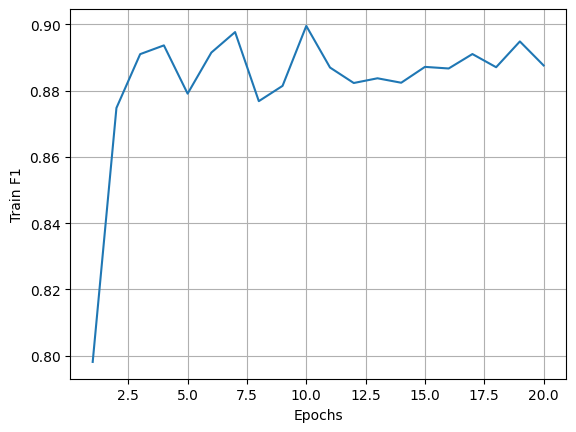

In [38]:
plt.plot(list(range(1, epochs + 1)), f1s_val)
plt.xlabel('Epochs')
plt.ylabel('Train F1')
plt.grid()
plt.show()

In [39]:
test_f1_metric.reset()
running_loss = 0.0
with torch.no_grad():
    for data in test_loader:
        images = data[0].to(device)
        labels = data[1].to(device)

        outputs = ViT_v2(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        test_f1_metric.update(outputs, labels)

loss_test = running_loss / len(test_loader)

test_f1 = test_f1_metric.compute().item()

print(f'Loss: {loss_test:.4f}, F1: {test_f1:.4f}')

model_f1s.append(test_f1)
model_names.append('ViT-Base 16 v2')

Loss: 0.4152, F1: 0.8725


# GoogLeNet

1. Без предобучения

In [40]:
GoogLeNet_v1 = models.googlenet(weights=None)
num_features = GoogLeNet_v1.fc.in_features
GoogLeNet_v1.fc = nn.Linear(num_features, 6)
optimizer = optim.Adam(GoogLeNet_v1.parameters(), lr=lr)

/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


In [41]:
val_losses = []
f1s_val = []

In [42]:
GoogLeNet_v1 = GoogLeNet_v1.to(device)

In [43]:
for epoch in range(epochs):
    GoogLeNet_v1.train()
    train_running_loss = 0.0
    train_f1_metric.reset()

    for data in (pbar := tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')):
        images = data[0].to(device)
        labels = data[1].to(device)

        optimizer.zero_grad()
        outputs = GoogLeNet_v1(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        train_running_loss += train_loss.item()
        train_f1_metric.update(outputs, labels)

    train_loss_ep = train_running_loss / len(train_loader)

    train_f1_ep = train_f1_metric.compute()

    print(f'Train loss: {train_loss_ep:.4f}')
    print(f'Train F1: {train_f1_ep.item():.4f}')

    GoogLeNet_v1.eval()
    val_running_loss = 0.0
    val_f1_metric.reset()

    with torch.no_grad():
        for data in val_loader:
            images = data[0].to(device)
            labels = data[1].to(device)

            outputs = GoogLeNet_v1(images)

            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item()
            val_f1_metric.update(outputs, labels)

    val_loss_ep = val_running_loss / len(val_loader)
    val_losses.append(val_loss_ep)

    val_f1_ep = val_f1_metric.compute()
    f1s_val.append(val_f1_ep.item())

    print(f'Validation loss: {val_loss_ep:.4f}')
    print(f'Validation F1: {val_f1_ep.item():.4f}')

Epoch 1/20: 100%|██████████| 28/28 [00:17<00:00,  1.58it/s]


Train loss: 1.5138
Train F1: 0.3379
Validation loss: 2.0856
Validation F1: 0.0538


Epoch 2/20: 100%|██████████| 28/28 [00:17<00:00,  1.60it/s]


Train loss: 1.2799
Train F1: 0.4476
Validation loss: 1.3496
Validation F1: 0.2932


Epoch 3/20: 100%|██████████| 28/28 [00:18<00:00,  1.54it/s]


...

Train loss: 0.5874
Train F1: 0.7791
Validation loss: 1.0011
Validation F1: 0.6394


Epoch 19/20: 100%|██████████| 28/28 [00:17<00:00,  1.58it/s]


Train loss: 0.6043
Train F1: 0.7602
Validation loss: 0.7335
Validation F1: 0.6662


Epoch 20/20: 100%|██████████| 28/28 [00:17<00:00,  1.61it/s]


Train loss: 0.5336
Train F1: 0.7866
Validation loss: 1.8101
Validation F1: 0.5065


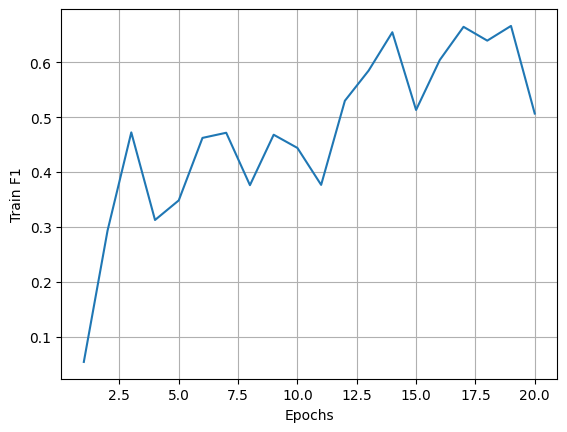

In [44]:
plt.plot(list(range(1, epochs + 1)), f1s_val)
plt.xlabel('Epochs')
plt.ylabel('Train F1')
plt.grid()
plt.show()

In [45]:
test_f1_metric.reset()
running_loss = 0.0
with torch.no_grad():
    for data in test_loader:
        images = data[0].to(device)
        labels = data[1].to(device)

        outputs = GoogLeNet_v1(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        test_f1_metric.update(outputs, labels)

loss_test = running_loss / len(test_loader)

test_f1 = test_f1_metric.compute().item()

print(f'Loss: {loss_test:.4f}, F1: {test_f1:.4f}')

model_f1s.append(test_f1)
model_names.append('GoogLeNet v1')

Loss: 1.8708, F1: 0.4795


 2. С весами, предобученными на ImageNet

In [46]:
GoogLeNet_v2 = models.googlenet(weights='IMAGENET1K_V1')
for params in GoogLeNet_v2.parameters():
        params.requires_grad = False
num_features = GoogLeNet_v2.fc.in_features
GoogLeNet_v2.fc = torch.nn.Sequential(nn.Linear(num_features, num_features // 2),
                                     nn.ReLU(),
                                     nn.Linear(num_features // 2, 6))
optimizer = optim.Adam(GoogLeNet_v2.parameters(), lr=lr)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 195MB/s]


In [47]:
val_losses = []
f1s_val = []

In [48]:
GoogLeNet_v2 = GoogLeNet_v2.to(device)

In [49]:
for epoch in range(epochs):
    GoogLeNet_v2.train()
    train_running_loss = 0.0
    train_f1_metric.reset()

    for data in (pbar := tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')):
        images = data[0].to(device)
        labels = data[1].to(device)

        optimizer.zero_grad()
        outputs = GoogLeNet_v2(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        train_running_loss += train_loss.item()
        train_f1_metric.update(outputs, labels)

    train_loss_ep = train_running_loss / len(train_loader)

    train_f1_ep = train_f1_metric.compute()

    print(f'Train loss: {train_loss_ep:.4f}')
    print(f'Train F1: {train_f1_ep.item():.4f}')

    GoogLeNet_v2.eval()
    val_running_loss = 0.0
    val_f1_metric.reset()

    with torch.no_grad():
        for data in val_loader:
            images = data[0].to(device)
            labels = data[1].to(device)

            outputs = GoogLeNet_v2(images)

            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item()
            val_f1_metric.update(outputs, labels)

    val_loss_ep = val_running_loss / len(val_loader)
    val_losses.append(val_loss_ep)

    val_f1_ep = val_f1_metric.compute()
    f1s_val.append(val_f1_ep.item())

    print(f'Validation loss: {val_loss_ep:.4f}')
    print(f'Validation F1: {val_f1_ep.item():.4f}')

Epoch 1/20: 100%|██████████| 28/28 [00:13<00:00,  2.04it/s]


Train loss: 1.1881
Train F1: 0.5057
Validation loss: 0.7547
Validation F1: 0.6596


Epoch 2/20: 100%|██████████| 28/28 [00:13<00:00,  2.08it/s]


Train loss: 0.6605
Train F1: 0.7353
Validation loss: 0.6327
Validation F1: 0.6874


Epoch 3/20: 100%|██████████| 28/28 [00:13<00:00,  2.07it/s]


...

Train loss: 0.2376
Train F1: 0.9095
Validation loss: 0.4936
Validation F1: 0.8078


Epoch 19/20: 100%|██████████| 28/28 [00:13<00:00,  2.07it/s]


Train loss: 0.3150
Train F1: 0.8740
Validation loss: 0.4526
Validation F1: 0.8268


Epoch 20/20: 100%|██████████| 28/28 [00:13<00:00,  2.09it/s]


Train loss: 0.2677
Train F1: 0.8935
Validation loss: 0.4146
Validation F1: 0.8623


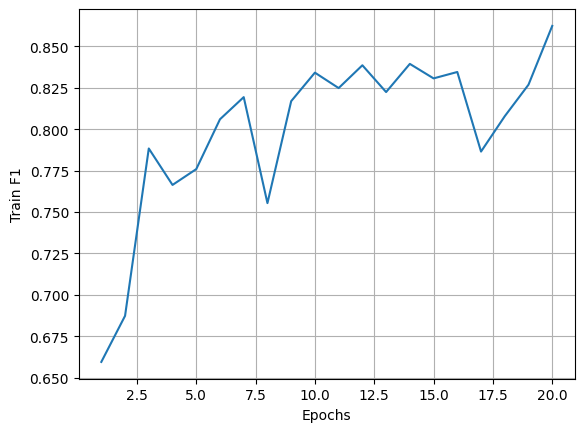

In [50]:
plt.plot(list(range(1, epochs + 1)), f1s_val)
plt.xlabel('Epochs')
plt.ylabel('Train F1')
plt.grid()
plt.show()

In [51]:
test_f1_metric.reset()
running_loss = 0.0
with torch.no_grad():
    for data in test_loader:
        images = data[0].to(device)
        labels = data[1].to(device)

        outputs = GoogLeNet_v2(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        test_f1_metric.update(outputs, labels)

loss_test = running_loss / len(test_loader)

test_f1 = test_f1_metric.compute().item()

print(f'Loss: {loss_test:.4f}, F1: {test_f1:.4f}')

model_f1s.append(test_f1)
model_names.append('GoogLeNet v2')

Loss: 0.5537, F1: 0.7868


# DenseNet 121

1. Без предобучения

In [52]:
DenseNet_v1 = models.densenet121(weights=None)
num_features = DenseNet_v1.classifier.in_features
DenseNet_v1.classifier = nn.Linear(num_features, 6)
optimizer = optim.Adam(DenseNet_v1.parameters(), lr=lr)

In [53]:
val_losses = []
f1s_val = []

In [54]:
DenseNet_v1 = DenseNet_v1.to(device)

In [55]:
for epoch in range(epochs):
    DenseNet_v1.train()
    train_running_loss = 0.0
    train_f1_metric.reset()

    for data in (pbar := tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')):
        images = data[0].to(device)
        labels = data[1].to(device)

        optimizer.zero_grad()
        outputs = DenseNet_v1(images)

        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        train_running_loss += train_loss.item()
        train_f1_metric.update(outputs, labels)

    train_loss_ep = train_running_loss / len(train_loader)

    train_f1_ep = train_f1_metric.compute()

    print(f'Train loss: {train_loss_ep:.4f}')
    print(f'Train F1: {train_f1_ep.item():.4f}')

    DenseNet_v1.eval()
    val_running_loss = 0.0
    val_f1_metric.reset()

    with torch.no_grad():
        for data in val_loader:
            images = data[0].to(device)
            labels = data[1].to(device)

            outputs = DenseNet_v1(images)

            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item()
            val_f1_metric.update(outputs, labels)

    val_loss_ep = val_running_loss / len(val_loader)
    val_losses.append(val_loss_ep)

    val_f1_ep = val_f1_metric.compute()
    f1s_val.append(val_f1_ep.item())

    print(f'Validation loss: {val_loss_ep:.4f}')
    print(f'Validation F1: {val_f1_ep.item():.4f}')

Epoch 1/20: 100%|██████████| 28/28 [00:28<00:00,  1.03s/it]


Train loss: 1.2695
Train F1: 0.4616
Validation loss: 1.2710
Validation F1: 0.5103


Epoch 2/20: 100%|██████████| 28/28 [00:28<00:00,  1.02s/it]


Train loss: 1.0487
Train F1: 0.5781
Validation loss: 1.0978
Validation F1: 0.5064


Epoch 3/20: 100%|██████████| 28/28 [00:28<00:00,  1.02s/it]


...

Train loss: 0.3670
Train F1: 0.8589
Validation loss: 0.5960
Validation F1: 0.7497


Epoch 19/20: 100%|██████████| 28/28 [00:28<00:00,  1.02s/it]


Train loss: 0.2674
Train F1: 0.8882
Validation loss: 0.5825
Validation F1: 0.7915


Epoch 20/20: 100%|██████████| 28/28 [00:29<00:00,  1.04s/it]


Train loss: 0.2792
Train F1: 0.8843
Validation loss: 0.7468
Validation F1: 0.7403


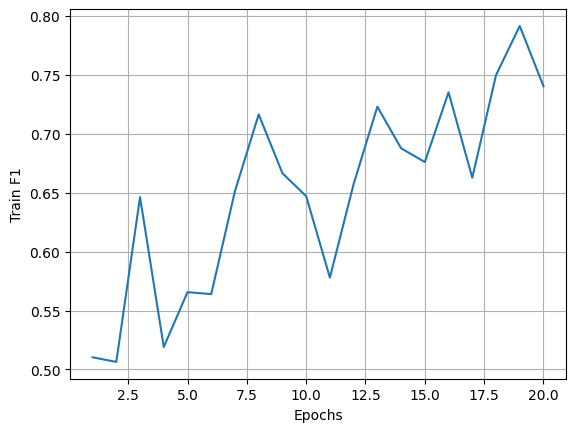

In [56]:
plt.plot(list(range(1, epochs + 1)), f1s_val)
plt.xlabel('Epochs')
plt.ylabel('Train F1')
plt.grid()
plt.show()

In [57]:
test_f1_metric.reset()
running_loss = 0.0
with torch.no_grad():
    for data in test_loader:
        images = data[0].to(device)
        labels = data[1].to(device)

        outputs = DenseNet_v1(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        test_f1_metric.update(outputs, labels)

loss_test = running_loss / len(test_loader)

test_f1 = test_f1_metric.compute().item()

print(f'Loss: {loss_test:.4f}, F1: {test_f1:.4f}')

model_f1s.append(test_f1)
model_names.append('DenseNet v1')

Loss: 0.7601, F1: 0.7342


 2. С весами, предобученными на ImageNet

In [58]:
DenseNet_v2 = models.densenet121(weights='IMAGENET1K_V1')
for params in DenseNet_v2.parameters():
        params.requires_grad = False
num_features = DenseNet_v2.classifier.in_features
DenseNet_v2.classifier = torch.nn.Sequential(nn.Linear(num_features, num_features // 2),
                                     nn.ReLU(),
                                     nn.Linear(num_features // 2, 6))
optimizer = optim.Adam(DenseNet_v2.parameters(), lr=lr)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 183MB/s]


In [59]:
val_losses = []
f1s_val = []

In [60]:
DenseNet_v2 = DenseNet_v2.to(device)

In [61]:
for epoch in range(epochs):
    DenseNet_v2.train()
    train_running_loss = 0.0
    train_f1_metric.reset()

    for data in (pbar := tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')):
        images = data[0].to(device)
        labels = data[1].to(device)

        optimizer.zero_grad()
        outputs = DenseNet_v2(images)

        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        train_running_loss += train_loss.item()
        train_f1_metric.update(outputs, labels)

    train_loss_ep = train_running_loss / len(train_loader)

    train_f1_ep = train_f1_metric.compute()

    print(f'Train loss: {train_loss_ep:.4f}')
    print(f'Train F1: {train_f1_ep.item():.4f}')

    DenseNet_v2.eval()
    val_running_loss = 0.0
    val_f1_metric.reset()

    with torch.no_grad():
        for data in val_loader:
            images = data[0].to(device)
            labels = data[1].to(device)

            outputs = DenseNet_v2(images)

            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item()
            val_f1_metric.update(outputs, labels)

    val_loss_ep = val_running_loss / len(val_loader)
    val_losses.append(val_loss_ep)

    val_f1_ep = val_f1_metric.compute()
    f1s_val.append(val_f1_ep.item())

    print(f'Validation loss: {val_loss_ep:.4f}')
    print(f'Validation F1: {val_f1_ep.item():.4f}')

Epoch 1/20: 100%|██████████| 28/28 [00:17<00:00,  1.64it/s]


Train loss: 1.0999
Train F1: 0.5148
Validation loss: 0.5562
Validation F1: 0.7349


Epoch 2/20: 100%|██████████| 28/28 [00:17<00:00,  1.61it/s]


Train loss: 0.5371
Train F1: 0.7898
Validation loss: 0.4307
Validation F1: 0.8049


Epoch 3/20: 100%|██████████| 28/28 [00:17<00:00,  1.64it/s]


...

Train loss: 0.0677
Train F1: 0.9841
Validation loss: 0.3428
Validation F1: 0.8420


Epoch 19/20: 100%|██████████| 28/28 [00:17<00:00,  1.63it/s]


Train loss: 0.0586
Train F1: 0.9858
Validation loss: 0.3145
Validation F1: 0.8643


Epoch 20/20: 100%|██████████| 28/28 [00:17<00:00,  1.61it/s]


Train loss: 0.0531
Train F1: 0.9921
Validation loss: 0.3086
Validation F1: 0.8783


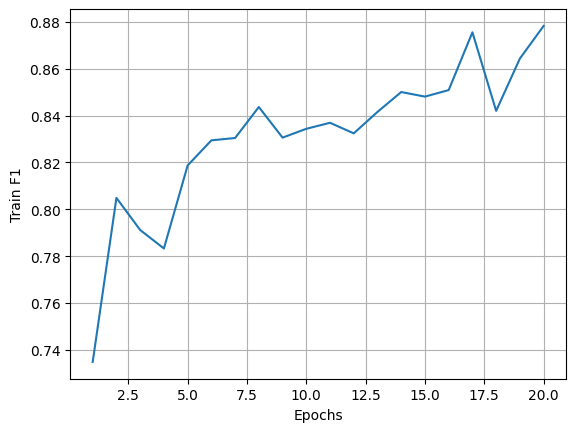

In [62]:
plt.plot(list(range(1, epochs + 1)), f1s_val)
plt.xlabel('Epochs')
plt.ylabel('Train F1')
plt.grid()
plt.show()

In [63]:
test_f1_metric.reset()
running_loss = 0.0
with torch.no_grad():
    for data in test_loader:
        images = data[0].to(device)
        labels = data[1].to(device)

        outputs = DenseNet_v2(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        test_f1_metric.update(outputs, labels)

loss_test = running_loss / len(test_loader)

test_f1 = test_f1_metric.compute().item()

print(f'Loss: {loss_test:.4f}, F1: {test_f1:.4f}')

model_f1s.append(test_f1)
model_names.append('DenseNet v2')

Loss: 0.5040, F1: 0.8364


# Сравнительная столбчатая диаграмма Macro F1-score

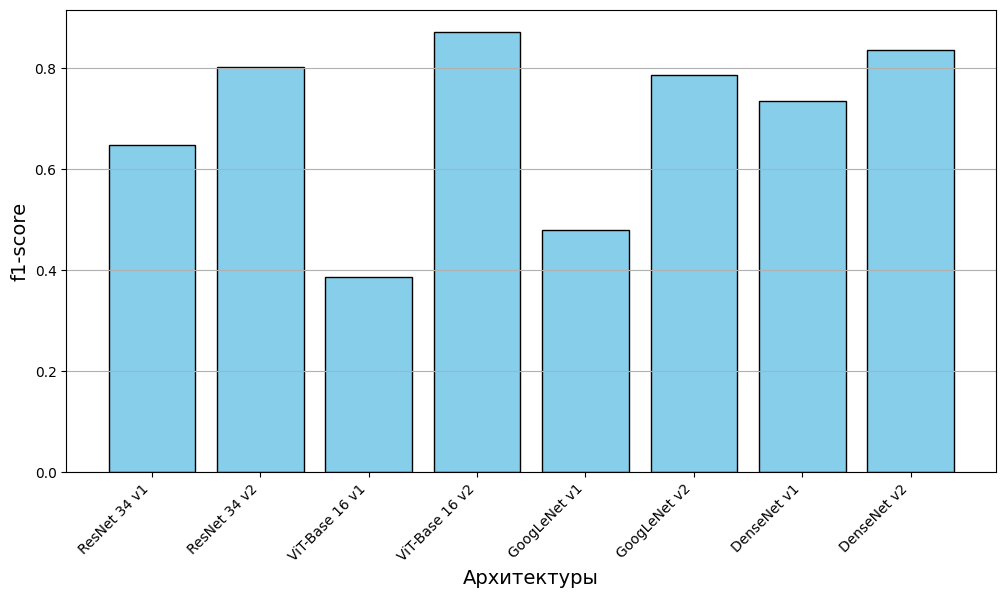

In [64]:
plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, model_f1s, color = 'skyblue', edgecolor = 'black')
plt.xlabel('Архитектуры', fontsize = 14)
plt.ylabel('f1-score', fontsize = 14)
plt.xticks(rotation = 45, ha = 'right')
plt.grid(axis='y')
plt.show()

#